## TP de Machine Learning — Classification
**Nom Complet :** Mohammed NASSIRI

**Utilisateur GitHub :** PunchArm255

---

Ce notebook implémente **3 algorithmes de Classification** :
1. Régression Logistique
2. KNN (K Plus Proches Voisins)
3. SVM (Machine à Vecteurs de Support)

Chaque algorithme est comparé entre une implémentation **From Scratch** et **Scikit-Learn**.

La variable cible binaire est créée à partir de la médiane du coût médical :
- **1** = Coût Élevé (≥ médiane)
- **0** = Coût Faible (< médiane)

### IMPORTATION DES BIBLIOTHÈQUES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
%matplotlib inline

### IMPLÉMENTATIONS FROM SCRATCH

In [2]:
class LogisticRegressionFromScratch:
    """Régression logistique via la descente de gradient."""
    def __init__(self, lr=0.1, n_iter=1000):
        self.lr = lr; self.n_iter = n_iter; self.w = None; self.b = None
    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    def fit(self, X, y):
        n, m = X.shape; self.w = np.zeros(m); self.b = 0.0
        for _ in range(self.n_iter):
            p = self._sigmoid(X.dot(self.w) + self.b)
            self.w -= self.lr * (1/n) * X.T.dot(p - y)
            self.b -= self.lr * (1/n) * np.sum(p - y)
    def predict(self, X):
        return (self._sigmoid(X.dot(self.w) + self.b) >= 0.5).astype(int)

class KNNFromScratch:
    """K Plus Proches Voisins via distance euclidienne et vote majoritaire."""
    def __init__(self, k=5):
        self.k = k
    def fit(self, X, y):
        self.X = np.array(X); self.y = np.array(y)
    def predict(self, X):
        X = np.array(X); preds = []
        for x in X:
            d = np.sqrt(np.sum((self.X - x)**2, axis=1))
            idx = np.argsort(d)[:self.k]
            preds.append(int(np.round(np.mean(self.y[idx]))))
        return np.array(preds)

### PRÉPARATION DES DONNÉES

In [3]:
df = pd.read_csv('data/medical_costs.csv')
median_cost = np.median(df['cost'].values)
y_class = (df['cost'].values >= median_cost).astype(int)
X_class = df[['age', 'bmi']].values

X_train, X_test, y_train, y_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Grille pour frontières de décision
h = 0.5
x_min, x_max = X_class[:,0].min()-2, X_class[:,0].max()+2
y_min, y_max = X_class[:,1].min()-2, X_class[:,1].max()+2
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid)
colors = np.where(y_class==1, '#e74c3c', '#3498db')
print(f"Échantillons : {len(df)} | Seuil médiane : {median_cost:.2f}")

Échantillons : 500 | Seuil médiane : 17141.39


### TEST 1 : RÉGRESSION LOGISTIQUE
La régression logistique utilise la fonction **sigmoïde** pour classifier les patients en coût élevé ou faible.

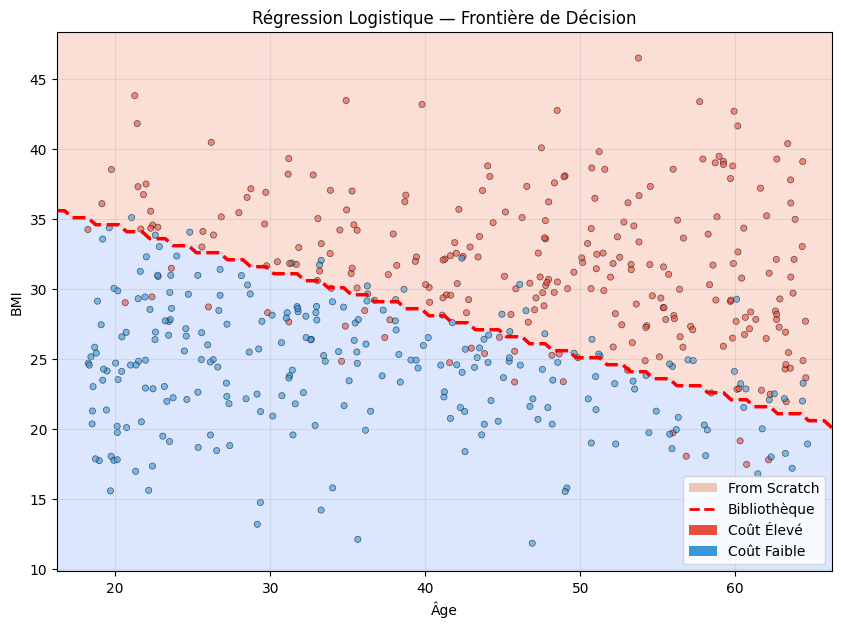

In [4]:
m_scratch = LogisticRegressionFromScratch()
m_scratch.fit(X_train_scaled, y_train)
m_sklearn = SklearnLogisticRegression(max_iter=1000)
m_sklearn.fit(X_train_scaled, y_train)

Z1 = m_scratch.predict(grid_scaled).reshape(xx.shape)
Z2 = m_sklearn.predict(grid_scaled).reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z1, alpha=0.3, cmap='coolwarm', levels=np.linspace(-0.5,1.5,3))
plt.contour(xx, yy, Z2, colors='red', linestyles='dashed', linewidths=2.5, levels=[0.5])
plt.scatter(X_class[:,0], X_class[:,1], c=colors, edgecolors='black', s=20, alpha=0.6, linewidths=0.5)
plt.title('Régression Logistique — Frontière de Décision')
plt.xlabel('Âge'); plt.ylabel('BMI')
plt.legend(handles=[
    Patch(facecolor='#d35400', alpha=0.3, label='From Scratch'),
    Line2D([0],[0], color='red', linestyle='dashed', linewidth=2, label='Bibliothèque'),
    Patch(facecolor='#e74c3c', label='Coût Élevé'),
    Patch(facecolor='#3498db', label='Coût Faible')])
plt.grid(True, alpha=0.3); plt.show()

### TEST 2 : KNN (K Plus Proches Voisins)
KNN classe chaque point en regardant les **K=5 voisins** les plus proches et en effectuant un **vote majoritaire**.

Calcul des frontières de décision KNN...
Terminé !


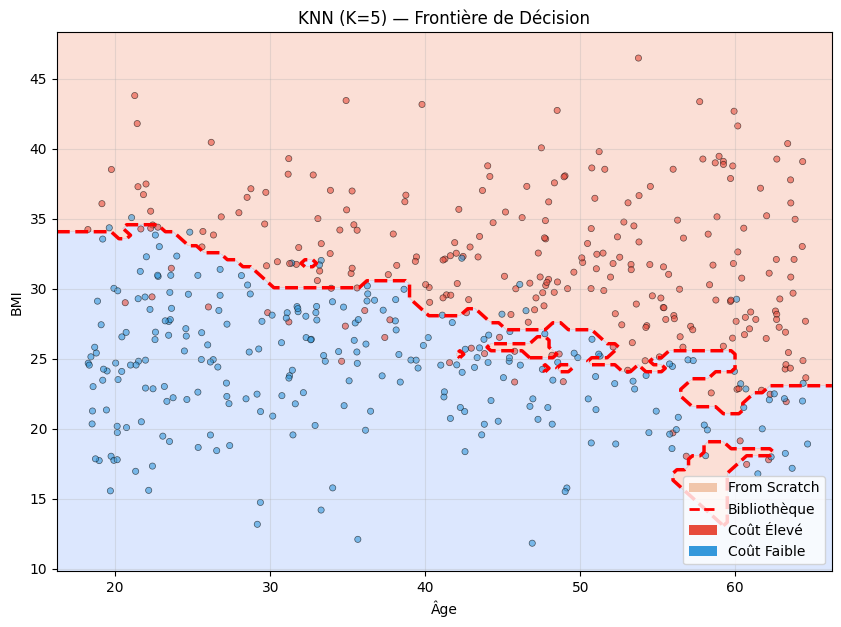

In [5]:
m_scratch = KNNFromScratch(k=5)
m_scratch.fit(X_train_scaled, y_train)
m_sklearn = KNeighborsClassifier(n_neighbors=5)
m_sklearn.fit(X_train_scaled, y_train)

print('Calcul des frontières de décision KNN...')
Z1 = m_scratch.predict(grid_scaled).reshape(xx.shape)
Z2 = m_sklearn.predict(grid_scaled).reshape(xx.shape)
print('Terminé !')

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z1, alpha=0.3, cmap='coolwarm', levels=np.linspace(-0.5,1.5,3))
plt.contour(xx, yy, Z2, colors='red', linestyles='dashed', linewidths=2.5, levels=[0.5])
plt.scatter(X_class[:,0], X_class[:,1], c=colors, edgecolors='black', s=20, alpha=0.6, linewidths=0.5)
plt.title('KNN (K=5) — Frontière de Décision')
plt.xlabel('Âge'); plt.ylabel('BMI')
plt.legend(handles=[
    Patch(facecolor='#d35400', alpha=0.3, label='From Scratch'),
    Line2D([0],[0], color='red', linestyle='dashed', linewidth=2, label='Bibliothèque'),
    Patch(facecolor='#e74c3c', label='Coût Élevé'),
    Patch(facecolor='#3498db', label='Coût Faible')])
plt.grid(True, alpha=0.3); plt.show()

### TEST 3 : SVM (Machine à Vecteurs de Support)
Le SVM cherche l'**hyperplan optimal** séparant les classes. On compare un **noyau linéaire** et un **noyau RBF** (Gaussien).

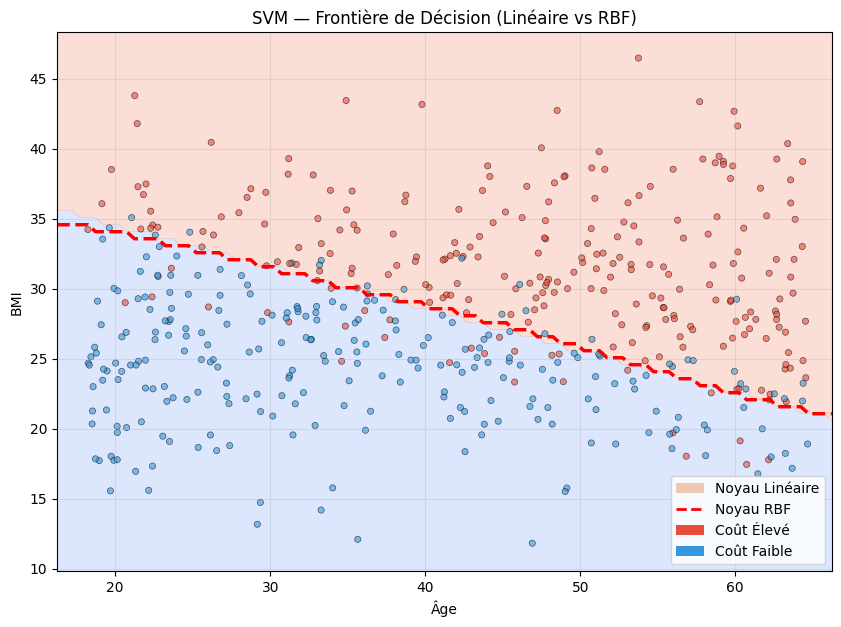

In [6]:
m_linear = SVC(kernel='linear'); m_linear.fit(X_train_scaled, y_train)
m_rbf = SVC(kernel='rbf'); m_rbf.fit(X_train_scaled, y_train)

Z1 = m_linear.predict(grid_scaled).reshape(xx.shape)
Z2 = m_rbf.predict(grid_scaled).reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z1, alpha=0.3, cmap='coolwarm', levels=np.linspace(-0.5,1.5,3))
plt.contour(xx, yy, Z2, colors='red', linestyles='dashed', linewidths=2.5, levels=[0.5])
plt.scatter(X_class[:,0], X_class[:,1], c=colors, edgecolors='black', s=20, alpha=0.6, linewidths=0.5)
plt.title('SVM — Frontière de Décision (Linéaire vs RBF)')
plt.xlabel('Âge'); plt.ylabel('BMI')
plt.legend(handles=[
    Patch(facecolor='#d35400', alpha=0.3, label='Noyau Linéaire'),
    Line2D([0],[0], color='red', linestyle='dashed', linewidth=2, label='Noyau RBF'),
    Patch(facecolor='#e74c3c', label='Coût Élevé'),
    Patch(facecolor='#3498db', label='Coût Faible')])
plt.grid(True, alpha=0.3); plt.show()